The water treatment plant of our city has contacted us, the plant operators reported that DBO-S, SS-S and DQO-S sensors share a common electrical panel scheduled for replacement. Since the plant cannot stop  during the renewal, they require a reliable method to estimate these values during that time. To address this they sent us 1 year of data taken day by day. 

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re 
water_treatment_data = pd.read_csv(r"Datasets/datos/water+treatment+plant/water-treatment.csv")  #We start by loading the data
water_treatment_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 39 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   D-1/3/90  526 non-null    str    
 1   44101     526 non-null    str    
 2   1.50      526 non-null    str    
 3   7.8       526 non-null    float64
 4   ?         526 non-null    str    
 5   407       526 non-null    str    
 6   166       526 non-null    str    
 7   66.3      526 non-null    str    
 8   4.5       526 non-null    str    
 9   2110      526 non-null    int64  
 10  7.9       526 non-null    float64
 11  ?.1       526 non-null    str    
 12  228       526 non-null    int64  
 13  70.2      526 non-null    str    
 14  5.5       526 non-null    str    
 15  2120      526 non-null    int64  
 16  7.9.1     526 non-null    float64
 17  ?.2       526 non-null    str    
 18  280       526 non-null    str    
 19  94        526 non-null    str    
 20  72.3      526 non-null    str    
 21  0.3 

As we can see the data has no headers, in order to facilitate the operations we are going to insert them.

In [29]:
variable_names = [
    'Date', 'Q-E', 'ZN-E', 'PH-E', 'DBO-E', 'DQO-E', 'SS-E', 'SSV-E', 'SED-E', 'COND-E', 
    'PH-P', 'DBO-P', 'SS-P', 'SSV-P', 'SED-P', 'COND-P', 'PH-D', 'DBO-D', 'DQO-D', 
    'SS-D', 'SSV-D', 'SED-D', 'COND-D', 'PH-S', 'DBO-S', 'DQO-S', 'SS-S', 'SSV-S', 
    'SED-S', 'COND-S', 'RD-DBO-P', 'RD-SS-P', 'RD-SED-P', 'RD-DBO-S', 'RD-DQO-S', 
    'RD-DBO-G', 'RD-DQO-G', 'RD-SS-G', 'RD-SED-G'
] #This list is was reflected in the documentation of the data 
water_treatment_data.columns = variable_names
water_treatment_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 526 entries, 0 to 525
Data columns (total 39 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      526 non-null    str    
 1   Q-E       526 non-null    str    
 2   ZN-E      526 non-null    str    
 3   PH-E      526 non-null    float64
 4   DBO-E     526 non-null    str    
 5   DQO-E     526 non-null    str    
 6   SS-E      526 non-null    str    
 7   SSV-E     526 non-null    str    
 8   SED-E     526 non-null    str    
 9   COND-E    526 non-null    int64  
 10  PH-P      526 non-null    float64
 11  DBO-P     526 non-null    str    
 12  SS-P      526 non-null    int64  
 13  SSV-P     526 non-null    str    
 14  SED-P     526 non-null    str    
 15  COND-P    526 non-null    int64  
 16  PH-D      526 non-null    float64
 17  DBO-D     526 non-null    str    
 18  DQO-D     526 non-null    str    
 19  SS-D      526 non-null    str    
 20  SSV-D     526 non-null    str    
 21  SED-

Now we set the date as our index and format it to datetime which will facilitate our operations later.

In [30]:
water_treatment_data.set_index('Date',inplace=True)
water_treatment_data.index = pd.to_datetime(water_treatment_data.index.str.replace('D-', ''),format='%d/%m/%y')
water_treatment_data

,Q-E,ZN-E,PH-E,DBO-E,DQO-E,SS-E,SSV-E,SED-E,COND-E,PH-P,...,COND-S,RD-DBO-P,RD-SS-P,RD-SED-P,RD-DBO-S,RD-DQO-S,RD-DBO-G,RD-DQO-G,RD-SS-G,RD-SED-G
Date,,,,,,,,,,,,,,,,,,,,,
1990-03-02,39024,3.00,7.7,?,443,214,69.2,6.5,2660,7.7,...,2590,?,60.7,94.8,?,80.8,?,79.5,92.1,100
1990-03-04,32229,5.00,7.6,?,528,186,69.9,3.4,1666,7.7,...,1888,?,58.2,95.6,?,52.9,?,75.8,88.7,98.5
1990-03-05,35023,3.50,7.9,205,588,192,65.6,4.5,2430,7.8,...,1840,33.1,64.2,95.3,87.3,72.3,90.2,82.3,89.6,100
1990-03-06,36924,1.50,8.0,242,496,176,64.8,4.0,2110,7.9,...,2120,?,62.7,95.6,?,71.0,92.1,78.2,87.5,99.5
1990-03-07,38572,3.00,7.8,202,372,186,68.8,4.5,1644,7.8,...,1764,?,59.7,96.5,86.7,78.3,90.1,73.1,84.9,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1991-08-26,32723,0.16,7.7,93,252,176,56.8,2.3,894,7.7,...,942,?,62.3,93.3,69.8,75.9,79.6,78.6,96.6,99.6
1991-08-27,33535,0.32,7.8,192,346,172,68.6,4.0,988,7.8,...,950,?,58.3,97.8,83.0,59.1,91.1,74.6,90.7,100
1991-08-28,32922,0.30,7.4,139,367,180,64.4,3.0,1060,7.5,...,1136,?,65.0,97.1,76.2,66.4,82.0,77.1,88.9,99


As we can see the null values are represented with '?' we replace the with NaN and calculate the percentage of nan values of each column

In [31]:
water_treatment_data.replace('?', np.nan, inplace=True)
water_treatment_data = water_treatment_data.apply(pd.to_numeric) #We convert every value from String to numerical
null_percentages = water_treatment_data.isna().mean() * 100
null_report = null_percentages.to_frame(name='Per_NaN').sort_values(by='Per_NaN', ascending=False) #We calculate the amount of NaN values of each variable

print(null_report[null_report['Per_NaN'] > 0])

            Per_NaN
RD-DBO-P  11.596958
DBO-P      7.414449
RD-DBO-S   7.414449
RD-DBO-G   6.653992
RD-SED-G   5.893536
SED-S      5.323194
RD-SED-P   5.133080
DBO-D      5.133080
RD-DQO-S   4.942966
RD-DQO-G   4.752852
SED-D      4.752852
SED-E      4.752852
SED-P      4.562738
DBO-E      4.182510
DBO-S      4.182510
Q-E        3.422053
DQO-S      3.422053
SSV-S      3.231939
SSV-D      2.471483
SSV-P      2.091255
SSV-E      2.091255
DQO-D      1.711027
RD-SS-G    1.520913
DQO-E      1.140684
SS-S       0.950570
RD-SS-P    0.760456
ZN-E       0.570342
SS-D       0.380228
COND-S     0.190114
SS-E       0.190114
PH-S       0.190114


As we can see, none of them surpass the 20% failure threshold, so they all can be used. 

But since NaN values aren't desirable, we are going to fill them with the forward fill technique.

In [32]:
water_treatment_data = water_treatment_data.ffill()
water_treatment_data

,Q-E,ZN-E,PH-E,DBO-E,DQO-E,SS-E,SSV-E,SED-E,COND-E,PH-P,...,COND-S,RD-DBO-P,RD-SS-P,RD-SED-P,RD-DBO-S,RD-DQO-S,RD-DBO-G,RD-DQO-G,RD-SS-G,RD-SED-G
Date,,,,,,,,,,,,,,,,,,,,,
1990-03-02,39024.0,3.00,7.7,NaN,443.0,214.0,69.2,6.5,2660,7.7,...,2590.0,NaN,60.7,94.8,NaN,80.8,NaN,79.5,92.1,100.0
1990-03-04,32229.0,5.00,7.6,NaN,528.0,186.0,69.9,3.4,1666,7.7,...,1888.0,NaN,58.2,95.6,NaN,52.9,NaN,75.8,88.7,98.5
1990-03-05,35023.0,3.50,7.9,205.0,588.0,192.0,65.6,4.5,2430,7.8,...,1840.0,33.1,64.2,95.3,87.3,72.3,90.2,82.3,89.6,100.0
1990-03-06,36924.0,1.50,8.0,242.0,496.0,176.0,64.8,4.0,2110,7.9,...,2120.0,33.1,62.7,95.6,87.3,71.0,92.1,78.2,87.5,99.5
1990-03-07,38572.0,3.00,7.8,202.0,372.0,186.0,68.8,4.5,1644,7.8,...,1764.0,33.1,59.7,96.5,86.7,78.3,90.1,73.1,84.9,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1991-08-26,32723.0,0.16,7.7,93.0,252.0,176.0,56.8,2.3,894,7.7,...,942.0,40.8,62.3,93.3,69.8,75.9,79.6,78.6,96.6,99.6
1991-08-27,33535.0,0.32,7.8,192.0,346.0,172.0,68.6,4.0,988,7.8,...,950.0,40.8,58.3,97.8,83.0,59.1,91.1,74.6,90.7,100.0
1991-08-28,32922.0,0.30,7.4,139.0,367.0,180.0,64.4,3.0,1060,7.5,...,1136.0,40.8,65.0,97.1,76.2,66.4,82.0,77.1,88.9,99.0


As we can see there are some NaN values in the first registers that can't be solved with the fordward fill technique, to solve this we use the backward fill so we assure there are not any NaN

In [33]:
water_treatment_data = water_treatment_data.bfill()
total_nans = water_treatment_data.isna().sum().sum() #We make sure that we have not skipped any NaN
print(f"NaN values in the data frame: {total_nans}")

NaN values in the data frame: 0


Now that we have the NaN  removed, we can search for individual outliers. For this, we will use the Interquartile Range (IQR) Method, which is based on establishing a threshold and discriminating the values that are further away than an adjusted distance—in this case, 1.5 times the IQR.

In [34]:
#We implement the IQR and find the outliers
def detect_outliers_iqr(df, column): 
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]
    return outliers, lower_limit, upper_limit
#We create a dataset to store the info about each variable
outliers_summary = []
numeric_columns = water_treatment_data.select_dtypes(include=['number']).columns
for col in numeric_columns:
    outliers, lower, upper = detect_outliers_iqr(water_treatment_data, col)
    outliers_summary.append({
        'Variable': col,
        'N_Outliers': len(outliers),
        'Pct_Outliers': round(len(outliers) / len(water_treatment_data) * 100, 2),
        'Lower_Limit': round(lower, 2),
        'Upper_Limit': round(upper, 2)
    })

summary = pd.DataFrame(outliers_summary).sort_values('Pct_Outliers', ascending=False)
print(summary)

    Variable  N_Outliers  Pct_Outliers  Lower_Limit  Upper_Limit
20     SED-D          44          8.37        -0.25         0.95
5       SS-E          39          7.41        62.00       350.00
11      SS-P          39          7.41        52.00       404.00
31  RD-SED-P          36          6.84        77.50       107.10
36   RD-SS-G          36          6.84        79.50       101.10
25      SS-S          35          6.65        -1.00        39.00
37  RD-SED-G          34          6.46        98.25       101.05
1       ZN-E          33          6.27        -2.25         6.15
27     SED-S          33          6.27        -0.03         0.05
33  RD-DQO-S          30          5.70        44.03        94.02
19     SSV-D          26          4.94        50.73        96.72
34  RD-DBO-G          26          4.94        80.21        99.71
6      SSV-E          24          4.56        34.85        90.45
32  RD-DBO-S          23          4.37        70.90        98.10
12     SSV-P          20 

Now we are looking for anomal global messurements, for this we use Isolation Forest to look for the 5% most different messurements, we chose this model because of the amount of different variables we are facing.

In [35]:
from sklearn.ensemble import IsolationForest

modelo_outliers = IsolationForest(contamination=0.07, random_state=7)
water_treatment_data['Global_Outlier'] = modelo_outliers.fit_predict(water_treatment_data)
anomalies = water_treatment_data[water_treatment_data['Global_Outlier'] == -1]

Now we are going to represent the main markers of the cleanliness of the plant to look for any correlation or pattern.

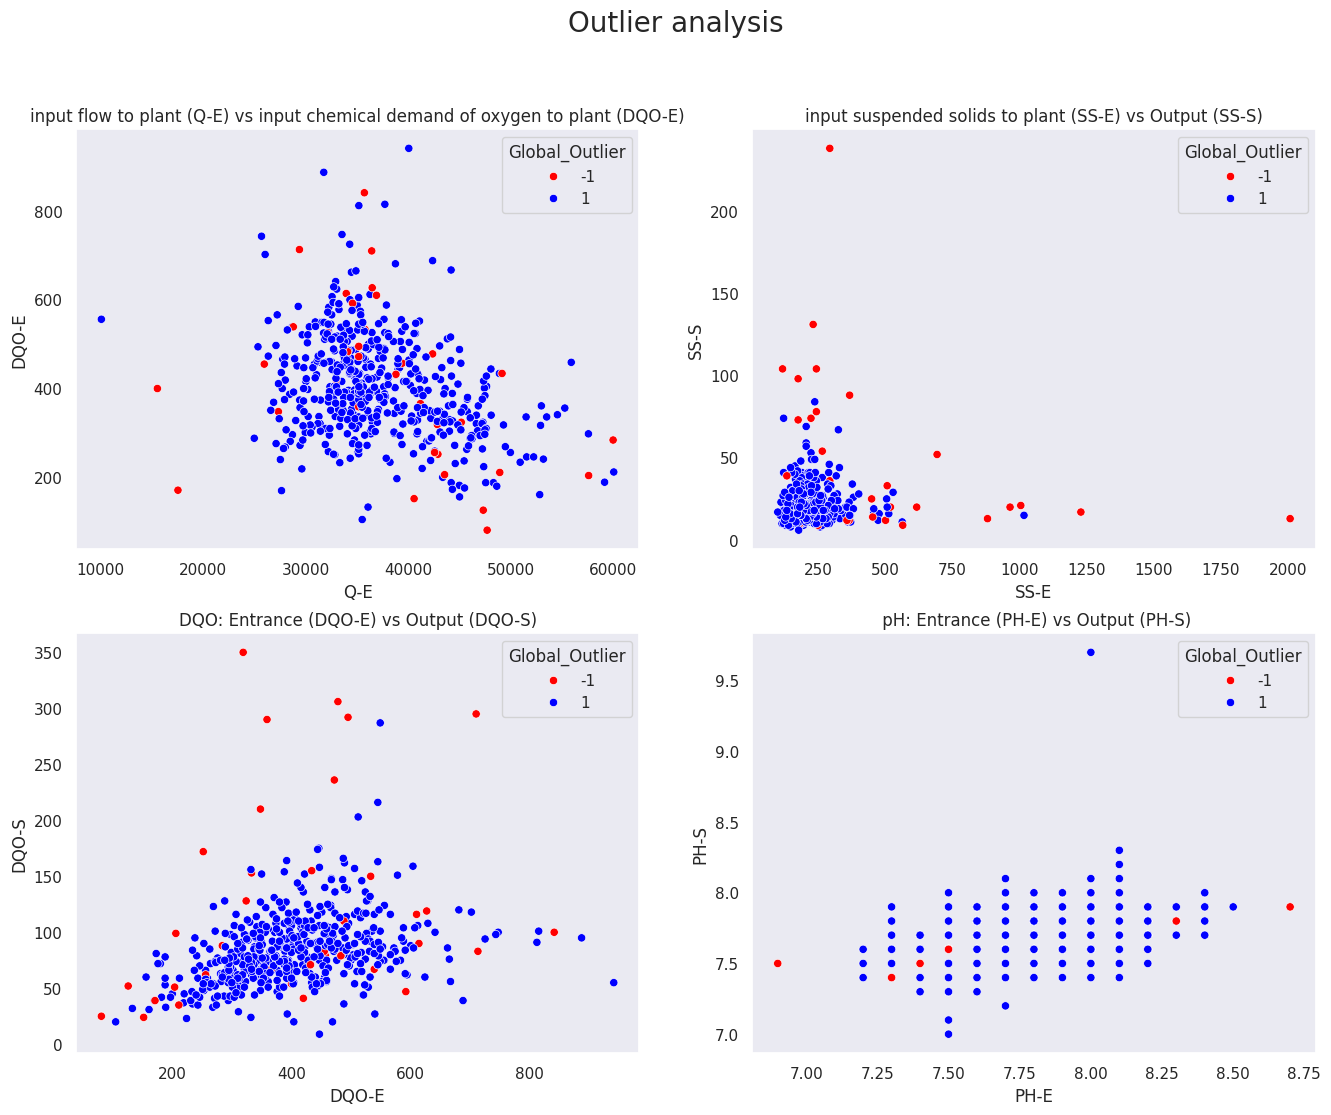

In [36]:
sns.set_theme(style="dark")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Outlier analysis', fontsize=20)

sns.scatterplot(ax=axes[0, 0], data=water_treatment_data, x='Q-E', y='DQO-E', 
                hue='Global_Outlier', palette={1: 'blue', -1: 'red'})
axes[0, 0].set_title('input flow to plant (Q-E) vs input chemical demand of oxygen to plant (DQO-E)')


sns.scatterplot(ax=axes[0, 1], data=water_treatment_data, x='SS-E', y='SS-S', 
                hue='Global_Outlier', palette={1: 'blue', -1: 'red'})
axes[0, 1].set_title('input suspended solids to plant (SS-E) vs Output (SS-S)')


sns.scatterplot(ax=axes[1, 0], data=water_treatment_data, x='DQO-E', y='DQO-S', 
                hue='Global_Outlier', palette={1: 'blue', -1: 'red'})
axes[1, 0].set_title('DQO: Entrance (DQO-E) vs Output (DQO-S)')


sns.scatterplot(ax=axes[1, 1], data=water_treatment_data, x='PH-E', y='PH-S', 
                hue='Global_Outlier', palette={1: 'blue', -1: 'red'})
axes[1, 1].set_title(' pH: Entrance (PH-E) vs Output (PH-S)')

plt.show()

Specially in the second plot we can observe that aproximately half of the annomal values are related with a high entrance of suspended solids , while the other values are reflected in the output. Through analisis we can conclude that SS processing is efficient with extreme inputs as the output remain normal, while with normal inputs the efficiency is reduced, since extreme outputs can be observe between the (200 - 300) range aprox.  



Now, after having our code cleaned, we are going to calculate and represent the correlation between the variables with the Pearsons method

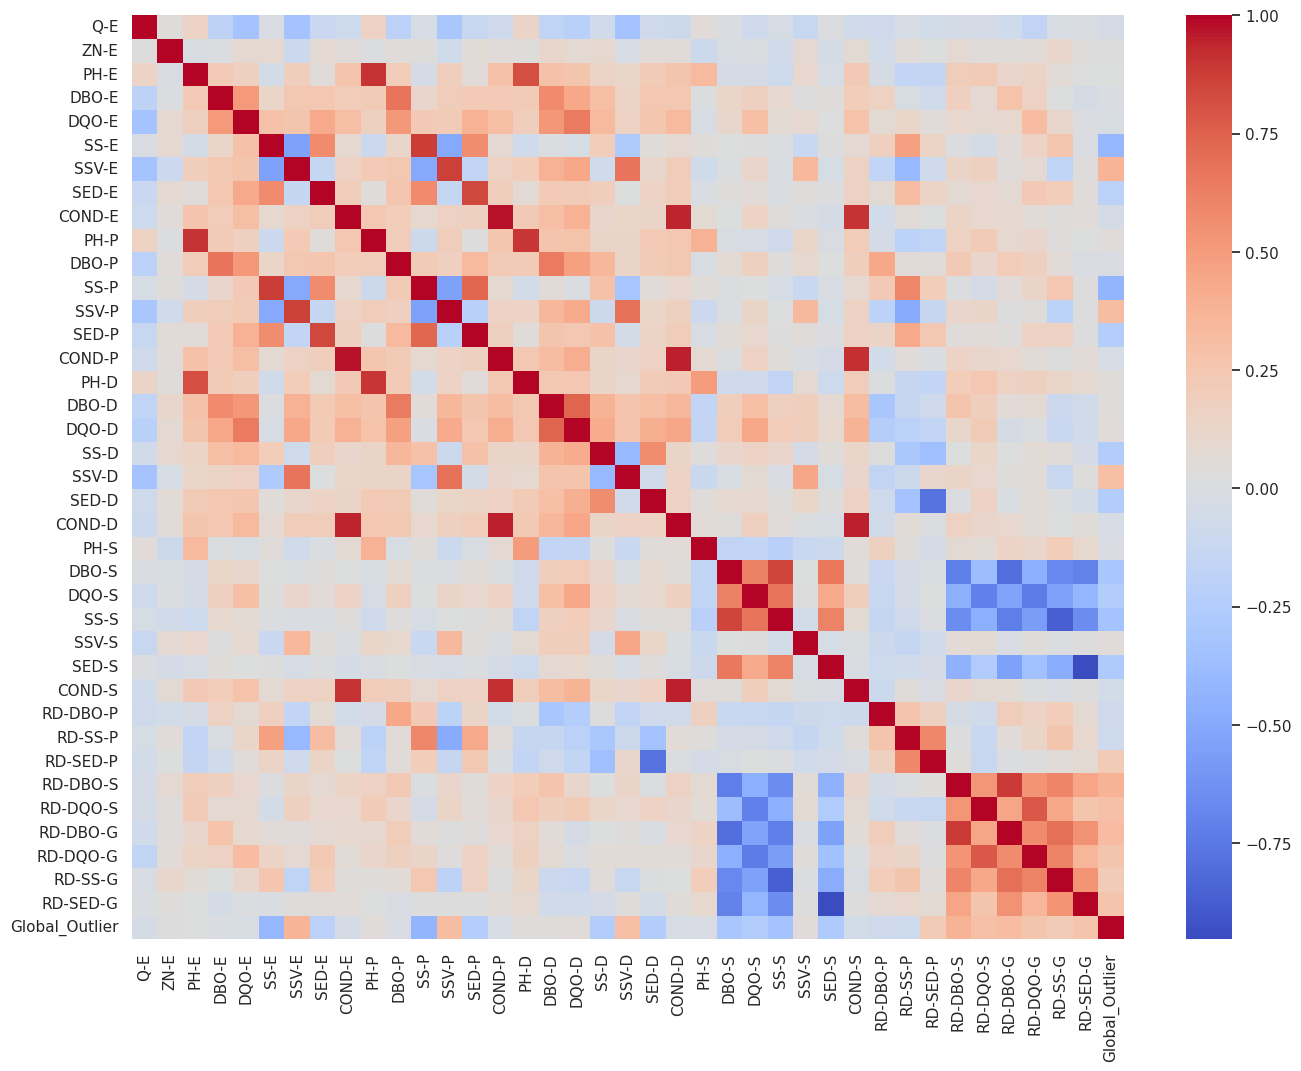

In [37]:
clean_data = water_treatment_data[water_treatment_data['Global_Outlier'] == 1]
plt.figure(figsize=(16, 12))
matrixCorr = water_treatment_data.corr()
sns.heatmap(matrixCorr,annot= False,cmap='coolwarm' )
plt.show()

Based on a visual review of the correlations and our research, we have concluded that the plant may require a full day to process the water. Specifically, we hypothesize that the output water on a given day is the result of the input from the previous day. To test this hypothesis, we are shifting the output data by one day and comparing the resulting correlation matrix.

In [38]:
#Firstly we calculate the mean value of corr of the previous matrix so we have a "score" of relation
meanNoLag = matrixCorr.mean().sum()
#Now we are going to create a DS with the input and primary messurements lagged a day
lags = water_treatment_data.iloc[:, 1:15].shift(1) 
new = pd.concat([lags, water_treatment_data.iloc[:, 15:]], axis=1).dropna()
matrixCorrLag = new.corr()
meanLag = matrixCorrLag.mean().sum()

print(f"The lag DataSet is {meanLag/meanNoLag} times better")


The lag DataSet is 0.85924640559188 times better


With this comparison we can conclude that our hypothesis was in fact incorrect. A lag likely exists in the treatment process, but it is shorter than a full day, meaning that a one-day shift produces a less representative dataset than the original. Since our measurements have a daily resolution, we cannot capture sub-daily lags. Therefore, we will work with the original unshifted dataset for analyses.



Now we are fully prepared to work on the problem, we will build a Digital Twin for each sensor using the remaining operational metrics as inputs. We will first establish a linear regression baseline; if the performance of the model is insufficient we will switch to a Random Forest regressor. Since the ground truth data is available, we will validate each twin by comparing predictions against real measurements.

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
import numpy as np

#Columns to eliminate
target_cols = ['DBO-S', 'SS-S', 'DQO-S']
drop_cols = ['DBO-S', 'SS-S', 'DQO-S', 'RD-DBO-S', 'RD-SS-G', 'RD-DQO-S', 'Global_Outlier']

X = water_treatment_data.drop(columns=drop_cols)
y = water_treatment_data[target_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2006
)

# Model pipeline
modelo_final = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Cross-validation
scores = cross_val_score(modelo_final, X_train, y_train, cv=5)
modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

#global metrics
test_r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
accuracy = (1 - mape) * 100

print(f"CV R² (Mean): {scores.mean():.4f}")
print(f"CV Std: {scores.std():.4f}")
print(f"Test R²: {test_r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"Accuracy (MAPE-based): {accuracy:.2f}%")

r2_per_value = r2_score(y_test, y_pred, multioutput='raw_values')
for col, r2_val in zip(target_cols, r2_per_value):
    print(f"R² {col}: {r2_val:.4f}")

# Accuracy per value (±10% relative error)
tolerancia = 0.10
for i, col in enumerate(target_cols):
    error_rel = np.abs((y_test.iloc[:, i] - y_pred[:, i]) / y_test.iloc[:, i])
    acc = np.mean(error_rel < tolerancia) * 100
    print(f"Accuracy {col} (±10%): {acc:.2f}%")

CV R² (Mean): 0.3143
CV Std: 0.5357
Test R²: 0.5534
MAE: 6.2119
Accuracy (MAPE-based): 77.21%
R² DBO-S: 0.3715
R² SS-S: 0.4076
R² DQO-S: 0.8812
Accuracy DBO-S (±10%): 28.30%
Accuracy SS-S (±10%): 18.87%
Accuracy DQO-S (±10%): 73.58%


As the score is that low, we are going to implement a random forest implementation.

In [40]:
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
modelo_final = make_pipeline(
    RandomForestRegressor(n_estimators=100, random_state=2006)
)

scores = cross_val_score(modelo_final, X_train, y_train, cv=5)
modelo_final.fit(X_train, y_train)
y_pred = modelo_final.predict(X_test)

# Metrics
test_r2 = modelo_final.score(X_test, y_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
accuracy = (1 - mape) * 100

print(f"CV R² Score (Promedio): {scores.mean():.4f}")
r2_per_value = r2_score(y_test, y_pred, multioutput='raw_values')
for col, r2_val in zip(target_cols, r2_per_value):
    print(f"R² {col}: {r2_val:.4f}")

print(f"Accuracy (MAPE-based): {accuracy:.2f}%")

tolerancia = 0.10
for i, col in enumerate(target_cols):
    error_rel = np.abs((y_test.iloc[:, i] - y_pred[:, i]) / y_test.iloc[:, i])
    acc = np.mean(error_rel < tolerancia) * 100
    print(f"Accuracy {col} (±10%): {acc:.2f}%")

CV R² Score (Promedio): 0.4155
R² DBO-S: 0.1489
R² SS-S: 0.4934
R² DQO-S: 0.9210
Accuracy (MAPE-based): 78.85%
Accuracy DBO-S (±10%): 32.08%
Accuracy SS-S (±10%): 27.36%
Accuracy DQO-S (±10%): 76.42%


To summarize the Digital Twin implementation: we recommend the SQO-S Random Forest model, which achieves 76% of predictions within a 10% error margin. If resources are limited, the Linear Regression model is a viable alternative, sacrificing some accuracy (73% within the same margin) for lower complexity. Conversely, the use of SS-S and DBO-S predictors is not advisable due to their poor performance.